In [1]:
import numpy as np
from kernelcpd import binseg
import matplotlib.pyplot as plt
import ruptures as rpt

np.random.seed(123)

### GROUND TRUTH (Choose one)

In [ ]:
# sample signal, 3 segments, 2 changepoints at index 29 and 59
seg_len = 30 # segment length
signal1 = np.column_stack((np.random.normal(1.0, 0.1, seg_len), np.random.normal(5.0, 0.1, seg_len)))
signal2 = np.column_stack((np.random.normal(5.0, 2.0, seg_len), np.random.normal(1.0, 2.0, seg_len)))
signal3 = np.column_stack((np.random.normal(1.0, 0.1, seg_len), np.random.normal(5.0, 0.1, seg_len)))
y = np.vstack((signal1, signal2, signal3))

bkps = [29, 59]

plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in bkps:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

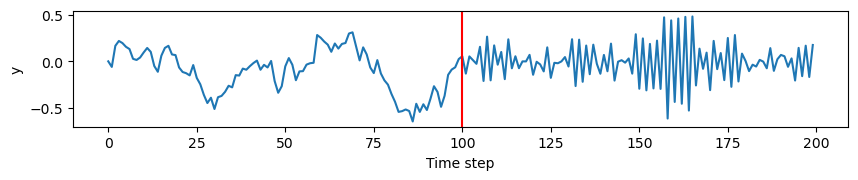

In [9]:
def generate_ar_change_data(n_samples=1000, bkp=500):
    res = np.zeros(n_samples)
    phi1 = [0.9]
    phi2 = [-0.9]
    noise = np.random.normal(0, 0.1, n_samples)
    for t in range(1, n_samples):
        if t < bkp:
            res[t] = phi1[0] * res[t-1] + noise[t]
        else:
            res[t] = phi2[0] * res[t-1] + noise[t]
    return res

y = generate_ar_change_data(200, 100)
y = y.reshape(-1, 1)

bkps = [100]

plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in bkps:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

In [ ]:
t = np.arange(200)
y = np.where(t<100, np.sin(2*np.pi*t*40/200), np.sin(2*np.pi*t*50/200)).reshape(-1,1)
y = y + np.random.normal(0, 0.8, 200).reshape(-1,1)

bkps = [100]

plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in bkps:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

### CHOOSE ONE METHOD

[19]


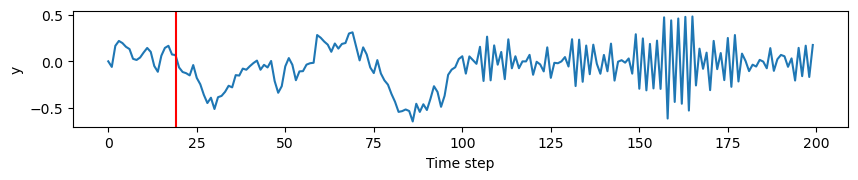

In [10]:
# detection
algo = rpt.Binseg(model="rbf").fit(y)
traditional_chpnts = np.array(algo.predict(n_bkps=1)[:-1]) - 1

print(traditional_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in traditional_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[98]


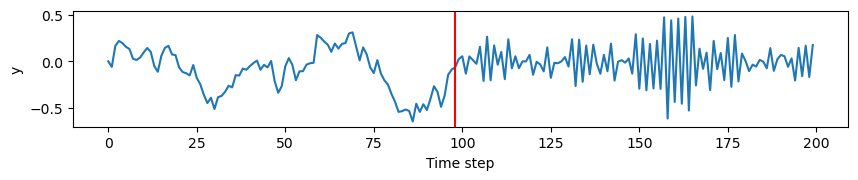

In [11]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 1, 
                        model = 'srbf', 
                        T = 1,
                        sigma = 1,
                        laplace_option = 'dirichlet',
                        laplace_hyperparameter = 1,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[157]


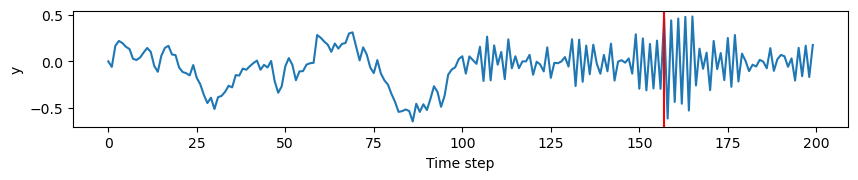

In [12]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 1, 
                        model = 'srbf', 
                        T = 2,
                        sigma = 1,
                        laplace_option = 'dirichlet',
                        laplace_hyperparameter = 1,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[94]


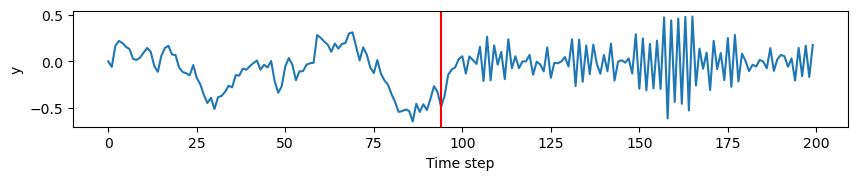

In [14]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 1, 
                        model = 'srbf', 
                        T = 3,
                        sigma = 1,
                        laplace_option = 'heat',
                        laplace_hyperparameter = 1,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

### TESTING

In [ ]:
from scipy.spatial.distance import pdist

def median_heuristic(X, kernel_type='gaussian'):
    if kernel_type == 'gaussian':
        distances = pdist(X, metric="euclidean")
        sigma = np.median(distances)
        return max(sigma, 1e-7)

    if kernel_type == 'laplace':
        distances = pdist(X, metric="cityblock")
        gamma = np.median(distances)
        return min(gamma**(-1), 1e7)

In [ ]:
median_heuristic(y, kernel_type='gaussian')